In [3]:
import gymnasium as gym
import itertools
import math
import matplotlib
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import random
import ale_py
import tensorflow as tf
from tensorflow.keras import layers

import torch
import torch.nn as nn
import torch.optim as optim


import subprocess, sys

import numpy as np
import seaborn as sns

from tqdm import tqdm
import collections

# Make plots look nice
sns.set()
sns.set_context("notebook")
sns.set_style("whitegrid")
gym.register_envs(ale_py)


env = gym.make("ALE/Asterix-v5", obs_type="grayscale", frameskip=1)


env = gym.wrappers.AtariPreprocessing(env, frame_skip=4)
env = gym.wrappers.FrameStackObservation(env, 4)


obs, info = env.reset()


#print("Observation space:", env.observation_space)
#print("Action space:", env.action_space)

for _ in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    #print(f"obs={obs}, reward={reward:.3f}, done={terminated}")

env.close()



class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)
    

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

replay_buffer = collections.deque(maxlen=100000)


    

In [4]:
def process_obs(obs):
    obs = np.array(obs, dtype=np.float32) / 255.0 
    return torch.tensor(obs, device=device).unsqueeze(0)

In [10]:
#Empty start

episode_rewards = []
train_losses = []
step_count = 0

n_actions = env.action_space.n
Q_net = DQN(n_actions).to(device)
T_net = DQN(n_actions).to(device)
T_net.load_state_dict(Q_net.state_dict())
T_net.eval()

optimizer = optim.Adam(Q_net.parameters(), lr=1e-4)

#only run this one on first go

action_space = env.action_space


print("Warming up replay buffer...")
while len(replay_buffer) < 5000:
    obs, info = env.reset()
    obs = process_obs(obs)
    done = False
    while not done and len(replay_buffer) < 5000:
        action = action_space.sample()
        next_obs, reward, terminated, truncated, info = env.step(action)
        reward = reward / 50.0
        next_obs = process_obs(next_obs)
        done = terminated or truncated
        replay_buffer.append([obs.cpu().numpy(), action, reward, next_obs.cpu().numpy(), terminated, truncated])
        obs = next_obs
print(f"Warmup done — buffer size: {len(replay_buffer)}")

start_episode = 0

Warming up replay buffer...
Warmup done — buffer size: 5000


In [6]:



def train_step(obss, actions, y_vals):
    Q_net.train()
    q_vals = Q_net(obss)
    chosen_q = q_vals.gather(1, actions.unsqueeze(1)).squeeze(1)
    td_error = torch.clamp(y_vals - chosen_q, -1, 1)
    loss = (td_error ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()



def save_checkpoint(path, Q_net, T_net, optimizer, step_count, episode_rewards, train_losses, episode):
    torch.save({
        'episode': episode,
        'step_count': step_count,
        'Q_net': Q_net.state_dict(),
        'T_net': T_net.state_dict(),
        'optimizer': optimizer.state_dict(),
        'episode_rewards': episode_rewards,
        'train_losses': train_losses,
    }, path)
    print(f"Checkpoint saved — episode {episode}, steps {step_count}")

def load_checkpoint(path, Q_net, T_net, optimizer):
    checkpoint = torch.load(path)
    Q_net.load_state_dict(checkpoint['Q_net'])
    T_net.load_state_dict(checkpoint['T_net'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    return (
        checkpoint['step_count'],
        checkpoint['episode_rewards'],
        checkpoint['train_losses'],
        checkpoint['episode']
    )

In [18]:
#load start

step_count, episode_rewards, train_losses, start_episode = load_checkpoint(
    "ddqn_checkpoint_ep5000.pt", Q_net, T_net, optimizer
)

In [21]:
print("Refilling buffer with on-policy experience...")
while len(replay_buffer) < 50000:
    obs, info = env.reset()
    obs = process_obs(obs)
    done = False
    while not done:
        with torch.no_grad():
            action = Q_net(obs).argmax(dim=1).item()  # use trained policy
        next_obs, reward, terminated, truncated, info = env.step(action)
        reward = reward / 50.0
        next_obs = process_obs(next_obs)
        done = terminated or truncated
        replay_buffer.append([obs.cpu().numpy(), action, reward,
                               next_obs.cpu().numpy(), terminated, truncated])
        obs = next_obs
print(f"Buffer refilled: {len(replay_buffer)} transitions")


Refilling buffer with on-policy experience...
Buffer refilled: 100000 transitions


In [15]:
replay_buffer = collections.deque(maxlen=100000)
discount = 0.99
action_space = env.action_space




x = start_episode

for x in range(start_episode, start_episode + 2001):
    eps = max(0.1, 1.0 - step_count / 100000)

    obs, info = env.reset()
    obs = process_obs(obs)
    done = False
    total_reward = 0
    total_reward_unscaled = 0
        

    if x % 20 == 0 and x > 0:
        recent_mean = np.mean(episode_rewards[-20:])
        recent_best = np.max(episode_rewards[-20:])
        print(f"Episode {x:4d} | eps={eps:.3f} | "
              f"mean={recent_mean:.1f} | best={recent_best:.1f} | "
              f"steps={step_count}")

    while not done:
        step_count += 1

        if step_count % 5000 == 0:
            T_net.load_state_dict(Q_net.state_dict())

        if random.random() > eps:
            with torch.no_grad():
                action = Q_net(obs).argmax(dim=1).item()
        else:
            action = action_space.sample()

        next_obs, reward, terminated, truncated, info = env.step(action)
        reward = reward / 50.0
        next_obs = process_obs(next_obs)
        done = terminated or truncated

        replay_buffer.append([obs.cpu().numpy(), action, reward, next_obs.cpu().numpy(), terminated, truncated])
        total_reward += reward
        total_reward_unscaled += reward * 50
        obs = next_obs

        if len(replay_buffer) > 1000:
            replays = random.sample(replay_buffer, 64)

            obss = torch.tensor(np.vstack([r[0] for r in replays]), device=device)
            actions = torch.tensor([r[1] for r in replays], device=device, dtype=torch.long)
            rewards = torch.tensor([r[2] for r in replays], device=device, dtype=torch.float32)
            next_obss = torch.tensor(np.vstack([r[3] for r in replays]), device=device)
            dones = torch.tensor([r[4] or r[5] for r in replays], device=device, dtype=torch.float32)

            with torch.no_grad():
                next_actions = Q_net(next_obss).argmax(dim=1)  # Q_net selects action
                q_vals = T_net(next_obss).gather(1, next_actions.unsqueeze(1)).squeeze(1)
            y_vals = rewards + discount * q_vals * (1 - dones)

            loss = train_step(obss, actions, y_vals)
            train_losses.append(loss)

    episode_rewards.append(total_reward_unscaled)
    print(f"Episode {x}, Reward: {total_reward_unscaled:.0f}")

    if x % 500 == 0 and x > 0:
        save_checkpoint(f"ddqn_checkpoint_ep{x}.pt", 
                    Q_net, T_net, optimizer, 
                    step_count, episode_rewards, train_losses, x)
        print(f"Checkpoint saved at episode {x}")

save_checkpoint(f"ddqn_checkpoint_ep{x}.pt", 
                    Q_net, T_net, optimizer, 
                    step_count, episode_rewards, train_losses, x)
print(f"Checkpoint saved at episode {x}")
env.close()

Episode 7002, Reward: 450
Episode 7003, Reward: 400
Episode 7004, Reward: 850
Episode 7005, Reward: 200
Episode 7006, Reward: 1100
Episode 7007, Reward: 350
Episode 7008, Reward: 550
Episode 7009, Reward: 750
Episode 7010, Reward: 750
Episode 7011, Reward: 550
Episode 7012, Reward: 500
Episode 7013, Reward: 350
Episode 7014, Reward: 450
Episode 7015, Reward: 600
Episode 7016, Reward: 300
Episode 7017, Reward: 250
Episode 7018, Reward: 350
Episode 7019, Reward: 150
Episode 7020 | eps=0.100 | mean=482.5 | best=1100.0 | steps=2062431
Episode 7020, Reward: 700
Episode 7021, Reward: 600
Episode 7022, Reward: 400
Episode 7023, Reward: 900
Episode 7024, Reward: 550
Episode 7025, Reward: 650
Episode 7026, Reward: 700
Episode 7027, Reward: 500
Episode 7028, Reward: 400
Episode 7029, Reward: 600
Episode 7030, Reward: 350
Episode 7031, Reward: 400
Episode 7032, Reward: 450
Episode 7033, Reward: 200
Episode 7034, Reward: 500
Episode 7035, Reward: 850
Episode 7036, Reward: 100
Episode 7037, Reward:

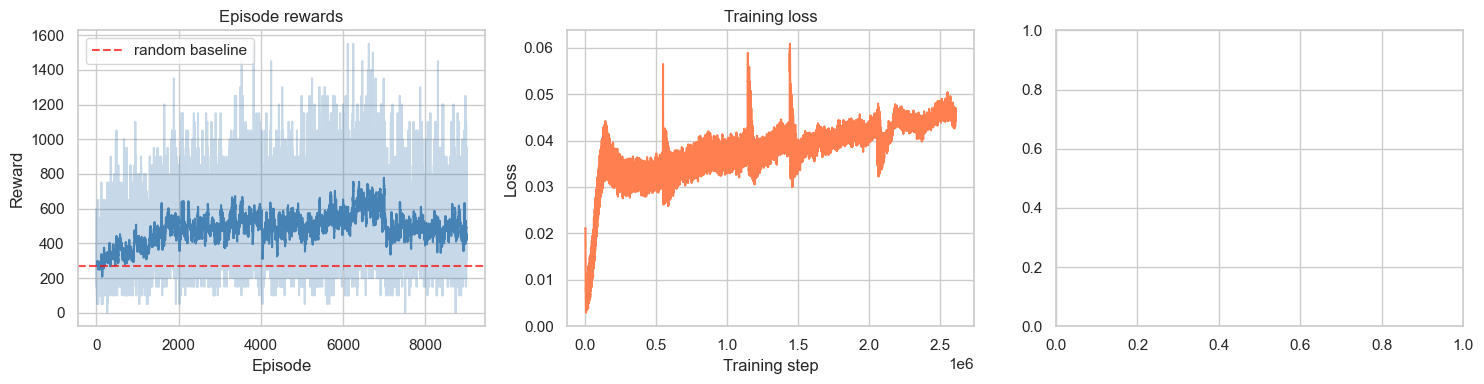

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def evaluate_agent(env, Q_net, device, n_episodes=20, eps=0.0):
    """Run n_episodes and return rewards. eps=0 for pure greedy, eps=0.05 for slight exploration."""
    Q_net.eval()
    rewards = []
    
    for ep in range(n_episodes):
        obs, info = env.reset()
        obs_t = process_obs(obs)
        done = False
        total = 0
        
        while not done:
            if random.random() > eps:
                with torch.no_grad():
                    action = Q_net(obs_t).argmax(dim=1).item()
            else:
                action = env.action_space.sample()
                
            obs, reward, terminated, truncated, info = env.step(action)
            obs_t = process_obs(obs)
            total += reward
            done = terminated or truncated
            
        rewards.append(total)
    
    Q_net.train()
    return rewards


def plot_training(episode_rewards, train_losses, eval_scores=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Raw + smoothed episode rewards
    rewards = np.array(episode_rewards)
    axes[0].plot(rewards, alpha=0.3, color='steelblue')
    if len(rewards) >= 20:
        smoothed = np.convolve(rewards, np.ones(20)/20, mode='valid')
        axes[0].plot(range(19, len(rewards)), smoothed, color='steelblue')
    axes[0].axhline(y=267, color='red', linestyle='--', alpha=0.7, label='random baseline')
    axes[0].set_title('Episode rewards')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Reward')
    axes[0].legend()
    
    # Smoothed loss
    if len(train_losses) > 0:
        losses = np.array(train_losses)
        if len(losses) >= 1000:
            smoothed_loss = np.convolve(losses, np.ones(1000)/1000, mode='valid')
            axes[1].plot(smoothed_loss, color='coral')
        else:
            axes[1].plot(losses, color='coral')
    axes[1].set_title('Training loss')
    axes[1].set_xlabel('Training step')
    axes[1].set_ylabel('Loss')
    
    # Periodic eval scores
    if eval_scores and len(eval_scores) > 0:
        eval_means = [np.mean(s) for s in eval_scores]
        eval_stds  = [np.std(s)  for s in eval_scores]
        x = range(len(eval_means))
        axes[2].plot(eval_means, color='green')
        axes[2].fill_between(x,
            np.array(eval_means) - np.array(eval_stds),
            np.array(eval_means) + np.array(eval_stds),
            alpha=0.2, color='green')
        axes[2].axhline(y=267, color='red', linestyle='--', alpha=0.7, label='random baseline')
        axes[2].set_title('Eval score over time')
        axes[2].set_xlabel('Eval checkpoint')
        axes[2].set_ylabel('Mean reward')
        axes[2].legend()
    
    plt.tight_layout()
    plt.show()


eval_scores = []

plot_training(episode_rewards, train_losses, eval_scores)